This notebook is focused on the question of whether **changes in spending within countries** is associated with improving LAYS. We recognise that establishing causality is beyond the scope of what we can achieve with the data we have, but we can look at associations. 

To do this we take two approaches
1. We use the all_data data set, mirroring the approach in notebook 01, but using country Fixed Effects to isolate the associations within countries rather than between countries. This gives us a sense of whether changing budgets *within* a country is correlated with changing LAYS. 
2. We use our annualised panel dataset to 

Final communication outputs are exported to `Results/figures/` and `Results/tables/`.

# **Load Packages**

In [2]:
#========================================
# Import required packages
#========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, Ellipse
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

from pathlib import Path
import json
import sys
sys.path.append(r"C:\Users\F.Turner\Documents\00. Analyses")
import use_funcs
from use_funcs import find_project_root

# **Create Helper Functions**

Define plotting palette and project path helpers used throughout the notebook.

In [3]:
#========================================
# Define Save the Children colour palette
#========================================

sc_colors = {'red': '#da291c',
             'medium red' : '#ed7b73',
             'light red': '#f9d3d0',
             'purple': '#ae90c3',
             'medium purple': '#cebcdb',
             'light purple': '#efe9f3',
             'yellow': '#fecf28',
             'medium yellow': '#ffeca9',
             'light yellow': '#fff5d4',
             'blue': '#99cccc',
             'medium blue' : '#d6ebeb',
             'light blue' : '#ebf5f5',
             'green' : '#45b283',
             'medium green' : '#8dd3b5',
             'light green' : '#d9f0e6',
             'grey' : '#e7e6e6'}

mpl.rcParams['font.family'] = 'Calibri' 

In [130]:
def oddsratio(model):
    # Extract coefficients and standard errors
    results_df = pd.DataFrame({
        'Coefficient': model.params,
        'Std Err': model.bse,
        'z': model.tvalues,
        'P>|z|': model.pvalues
    })

    # Add Odds Ratio column
    results_df['Odds Ratio'] = np.exp(results_df['Coefficient']).round(4)

    # Optional: Add 95% CI for Odds Ratios
    conf = model.conf_int()
    results_df['OR Lower CI'] = np.exp(conf[0]).round(4)
    results_df['OR Upper CI'] = np.exp(conf[1]).round(4)

    return results_df


In [4]:
#========================================
# Configure project paths and output folders
#========================================

PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / "path_config.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    PATHS = json.load(f)

IMP_DIR = (PROJECT_ROOT / PATHS["imports_dir"]).resolve()
HO_DIR = (PROJECT_ROOT / PATHS["handoff_dir"]).resolve()
EXP_DIR = (PROJECT_ROOT / PATHS["exports_dir"]).resolve()
FIG_DIR = (PROJECT_ROOT / PATHS["figures_dir"]).resolve()
TAB_DIR = (PROJECT_ROOT / PATHS["tables_dir"]).resolve()

for folder in [IMP_DIR, HO_DIR, EXP_DIR, FIG_DIR, TAB_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMP_DIR:", IMP_DIR)
print("HO_DIR:", HO_DIR)
print("EXP_DIR:", EXP_DIR)
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

PROJECT_ROOT: C:\Users\F.Turner\Documents\00. Analyses\Education Financing
IMP_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Data
HO_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Handoff
EXP_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results
FIG_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\figures
TAB_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\tables


# **Load Data**

Load the prepared merged datasets used in the modeling and visualization steps.

In [5]:
#========================================
# Load core analysis datasets
#========================================

all_data = pd.read_csv(IMP_DIR / "all_data.csv")
lays_panels = pd.read_csv(IMP_DIR / "lays_panels.csv")

In [ ]:
# Remove outliers in expenditure per child variable (values below 10 USD PPP are likely to be errors)

all_data['expenditure_perchild_ppp'].describe()
all_data = all_data.drop(all_data[all_data['expenditure_perchild_ppp'] < 10].index, axis=0)

# **Analysis**

## Do changes in GDPPC or per child expenditure Correlate with changes in LAYS?

This analysis uses panel data (as opposed to the cross sectional data used in notebook 1). This allows for country fixed effects to be used in regression models, trying to isolate change within countries over time (as opposed to between countries at one point in time). 

In [55]:
#===================================================================================
# Build multi-indexed base dataset for GDPPC-LAYS models with entity fixed effects
#===================================================================================

df = all_data.copy()
df = df.dropna(subset=["lays", "gdppc_2015_usd"])
df = df.drop(df[df['income_group'] == 'Not classified'].index, axis=0)
df = df[["iso3",
         "year",
         "income_group",
         "lays",
         "gdppc_2015_usd",
         'expenditure_perchild_ppp',
         'expenditure_pctbudget_uis',
        'expenditure_pctgdp'
         ]]

df = df.set_index(['iso3', 'year'])

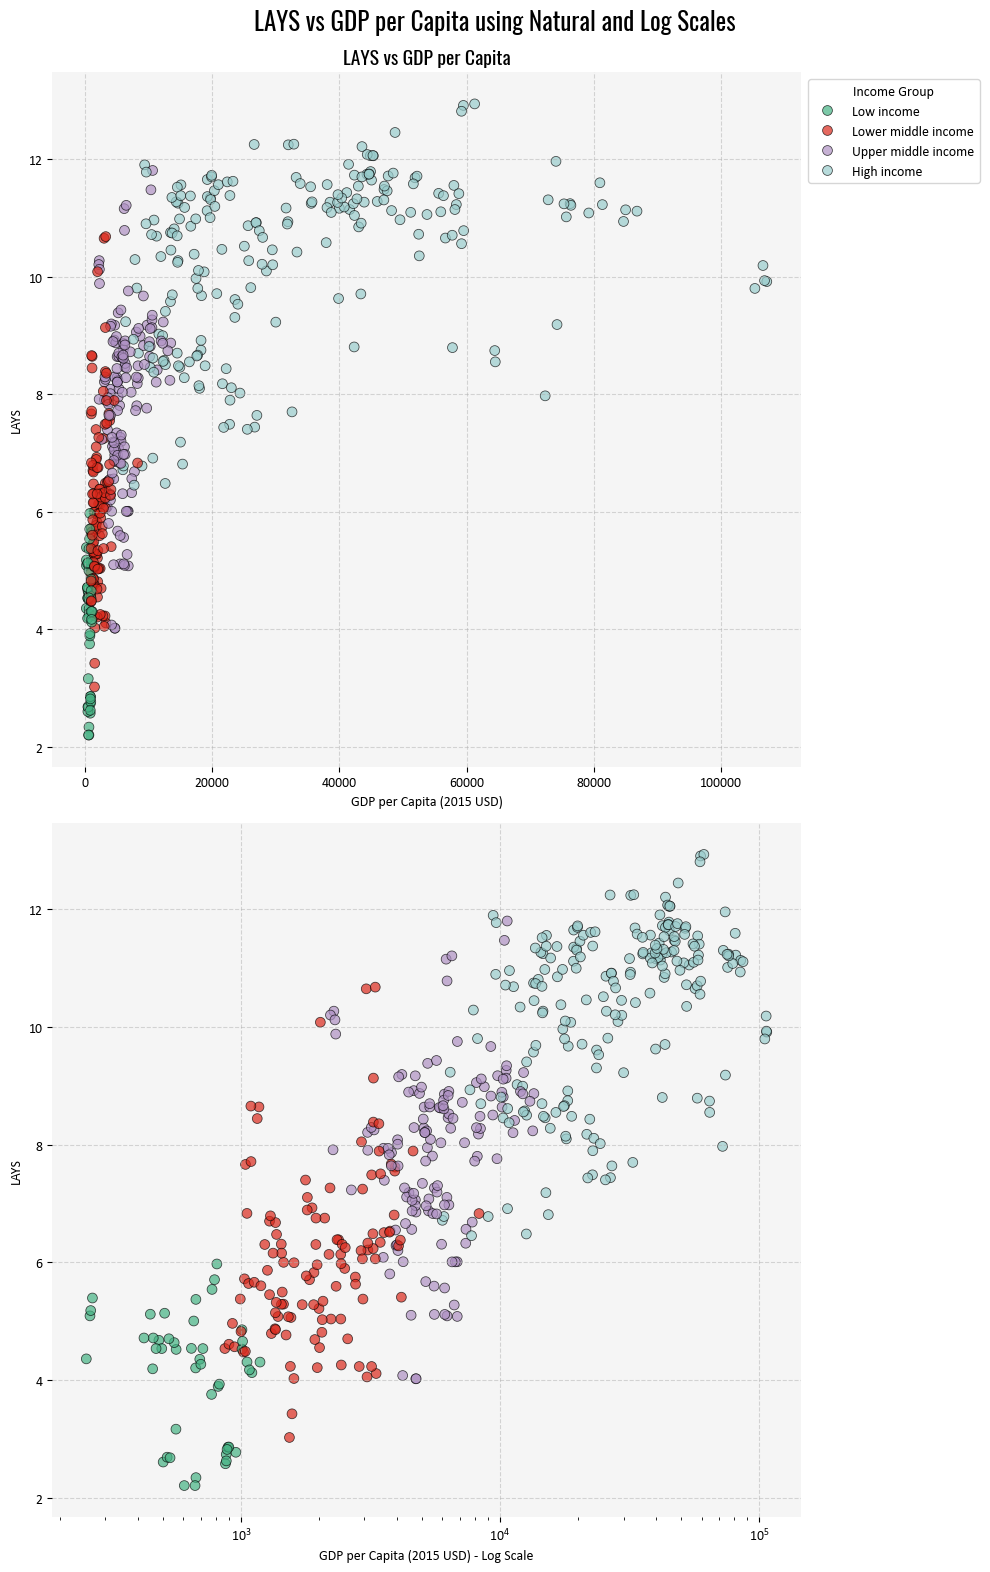

In [ ]:
#====================================================================================================
# Plot LAYS against GDPPC in level and log scale - keeping all entity/year observations to show overall relationship and variation by income group
#====================================================================================================

fig, ax = plt.subplots(2, 1, figsize=(10, 16))

ax = ax.flatten()

sns.scatterplot(
    data=df,
    x="gdppc_2015_usd",
    y="lays",
    hue="income_group",
    palette={
        "Low income": sc_colors["green"],
        "Lower middle income": sc_colors["red"],
        "Upper middle income": sc_colors["purple"],
        "High income": sc_colors["blue"],
    },
    edgecolor="black",
    alpha=0.7,
    s=50,
    ax=ax[0],
)

ax[0].set_title("LAYS vs GDP per Capita", fontsize=14, fontname='Oswald')
ax[0].set_xlabel("GDP per Capita (2015 USD)")
ax[0].set_ylabel("LAYS")
ax[0].legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1))


sns.scatterplot(data=df, x="gdppc_2015_usd", 
                y="lays", 
                hue="income_group",  
                palette = {"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue']},
                edgecolor='black',
                 alpha=0.7,
                 s=50,
                ax=ax[1])

ax[1].set_xscale("log")
ax[1].set_xlabel("GDP per Capita (2015 USD) - Log Scale")
ax[1].set_ylabel("LAYS")
ax[1].legend().set_visible(False)


for ax in ax.flatten():
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_facecolor('whitesmoke')
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

fig.suptitle("LAYS vs GDP per Capita using Natural and Log Scales", fontsize=18, fontname='Oswald')

plt.tight_layout(rect=[0, 0, 1, 0.99])

fig.savefig(FIG_DIR / "panel_lays_vs_gdppc_level_and_log.png", dpi=300, bbox_inches="tight")

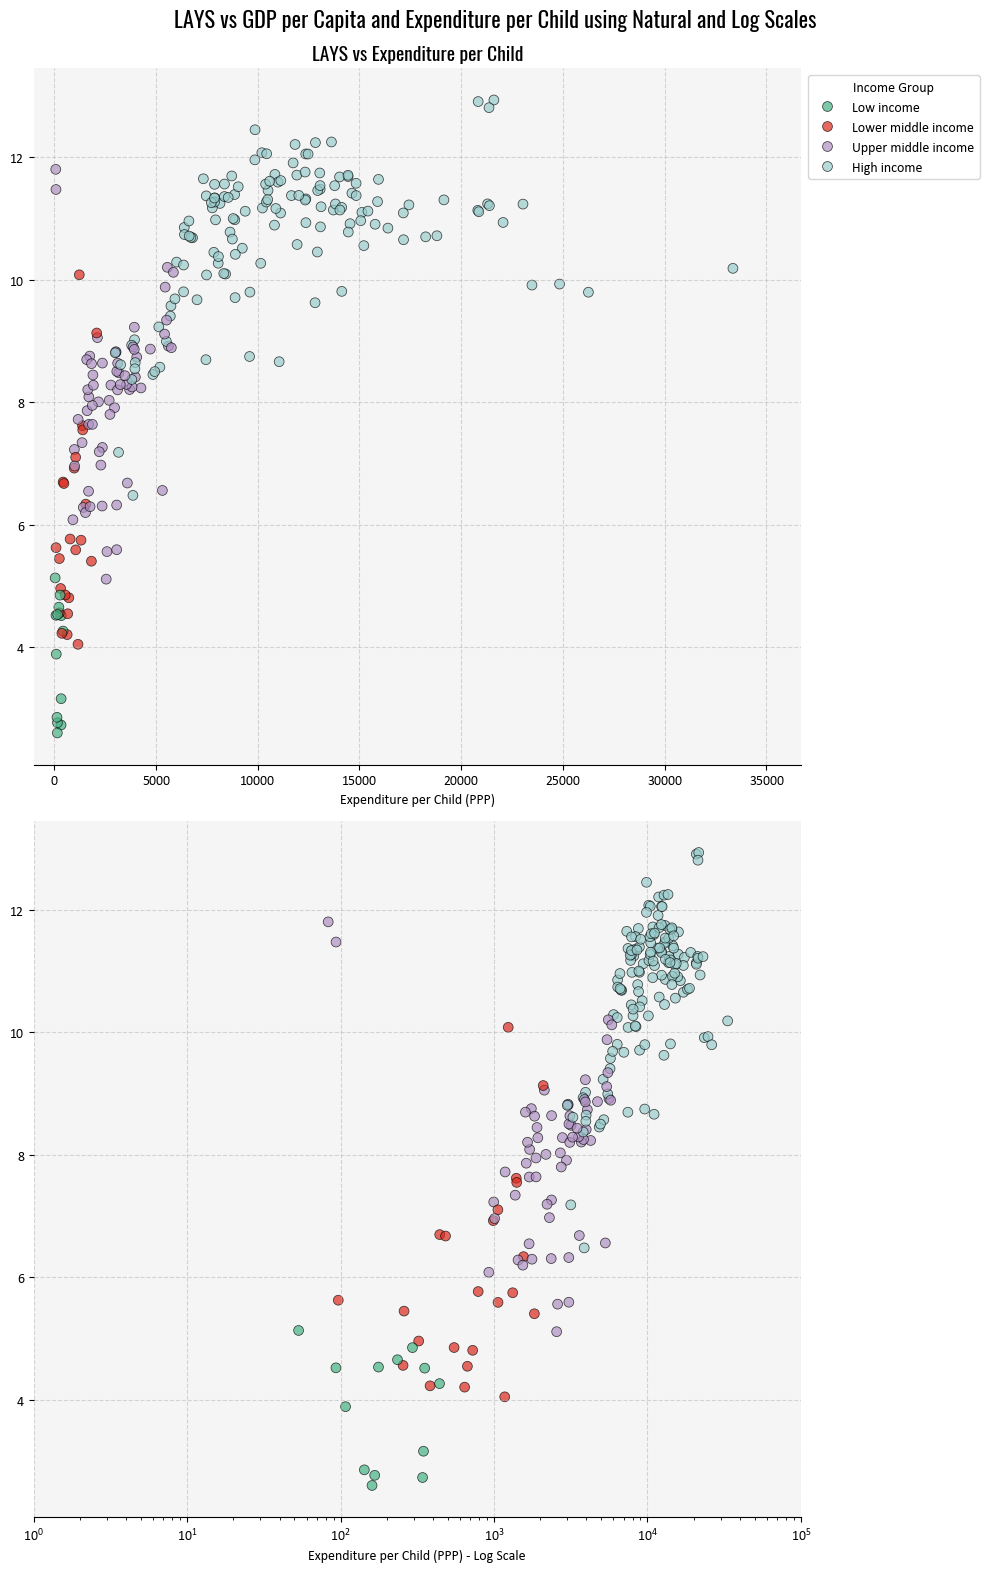

In [ ]:
#=====================================================================================================================
# Repeat using expenditure per child variable instead of GDPPC to show similar patterns and variation by income group
#=====================================================================================================================

fig, ax = plt.subplots(2, 1, figsize=(10, 16))

ax = ax.flatten()

sns.scatterplot(data=df, x="expenditure_perchild_ppp", 
                y="lays", 
                hue="income_group",  
                palette = {"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue']},
                edgecolor='black',
                 alpha=0.7,
                 s=50,
                ax=ax[0])

ax[0].set_title("LAYS vs Expenditure per Child", fontsize=14, fontname='Oswald')
ax[0].set_xlabel("Expenditure per Child (PPP)")
ax[0].set_ylabel("")
ax[0].set_xlim(-1000, df["expenditure_perchild_ppp"].max() * 1.1)
ax[0].legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1))


sns.scatterplot(data=df, x="expenditure_perchild_ppp", 
                y="lays", 
                hue="income_group",  
                palette = {"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue']},
                edgecolor='black',
                 alpha=0.7,
                 s=50,
                ax=ax[1])

ax[1].set_xlabel("Expenditure per Child (PPP) - Log Scale")
ax[1].set_xlim(1, 100000)
ax[1].set_ylabel("")
ax[1].set_xscale("log")
ax[1].legend().set_visible(False)


for ax in ax.flatten():
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_facecolor('whitesmoke')
    ax.spines[['top', 'right', 'left']].set_visible(False)

fig.suptitle("LAYS vs Expenditure per Child using Natural and Log Scales (panel data)", fontsize=16, fontname='Oswald')

plt.tight_layout(rect=[0, 0, 1, 0.99])

fig.savefig(FIG_DIR / "panel_lays_vs_expenditure_per_child_level_and_log.png", dpi=300, bbox_inches="tight")

### Do these Slopes Vary by Income Group

This repeats analysis done with our cross-sectional data to see if the patterns are consistent

In [56]:
#========================================
# Estimate interaction model across income groups
#========================================

df = df.copy()
df = df.rename(columns={"gdppc_2015_usd": "gdppc", 'expenditure_perchild_ppp': "pcppp"})
df['log_gdppc'] = np.log(df['gdppc'])
df['log_pcppp'] = np.log(df['pcppp'])

# Create income group dummies
dummies = pd.get_dummies(df["income_group"], prefix="inc", drop_first=True)
df = pd.concat([df, dummies], axis=1)

# MODEL 1 - Log-GDPPC with Income Group Dummies and Interactions
df1 = df.dropna(subset=["log_gdppc"]).copy()

y = df1["lays"]


# Create interaction terms
for col in dummies.columns:
    df1[f"log_gdppc_{col}"] = df1["log_gdppc"] * df1[col]

# Now build X
X_vars = ["log_gdppc"] + [f"log_gdppc_{col}" for col in dummies.columns]

X = df1[X_vars]
X = X.astype(float)  # Ensure all data is numeric
X = sm.add_constant(X)

model1 = PanelOLS(y, X, entity_effects=True).fit()
print("\n\nModel 1 - Log-GDPPC with Income Group Dummies (entity FE) and Interactions Summary:")
print(model1.summary)

# MODEL 2 - Log-PCPPP with Income Group Dummies and Interactions

df2 = df.dropna(subset=["log_pcppp"]).copy()

y = df2["lays"]

# Create interaction terms
for col in dummies.columns:
    df2[f"log_pcppp_{col}"] = df2["log_pcppp"] * df2[col]

# Now build X
X_vars = ["log_pcppp"] + [f"log_pcppp_{col}" for col in dummies.columns]

X = df2[X_vars]
X = X.astype(float)  # Ensure all data is numeric
X = sm.add_constant(X)

model2 = PanelOLS(y, X, entity_effects=True).fit()
print("\n\nModel 2 - Log-PCPPP with Income Group Dummies (entity FE) and Interactions Summary:")
print(model2.summary)




Model 1 - Log-GDPPC with Income Group Dummies (entity FE) and Interactions Summary:
                          PanelOLS Estimation Summary                           
Dep. Variable:                   lays   R-squared:                        0.1058
Estimator:                   PanelOLS   R-squared (Between):             -14.606
No. Observations:                 517   R-squared (Within):               0.1058
Date:                Tue, May 26 2026   R-squared (Overall):             -14.201
Time:                        15:29:12   Log-likelihood                   -110.48
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      10.413
Entities:                         161   P-value                           0.0000
Avg Obs:                       3.2112   Distribution:                   F(4,352)
Min Obs:                       1.0000                                           
Max Obs:               

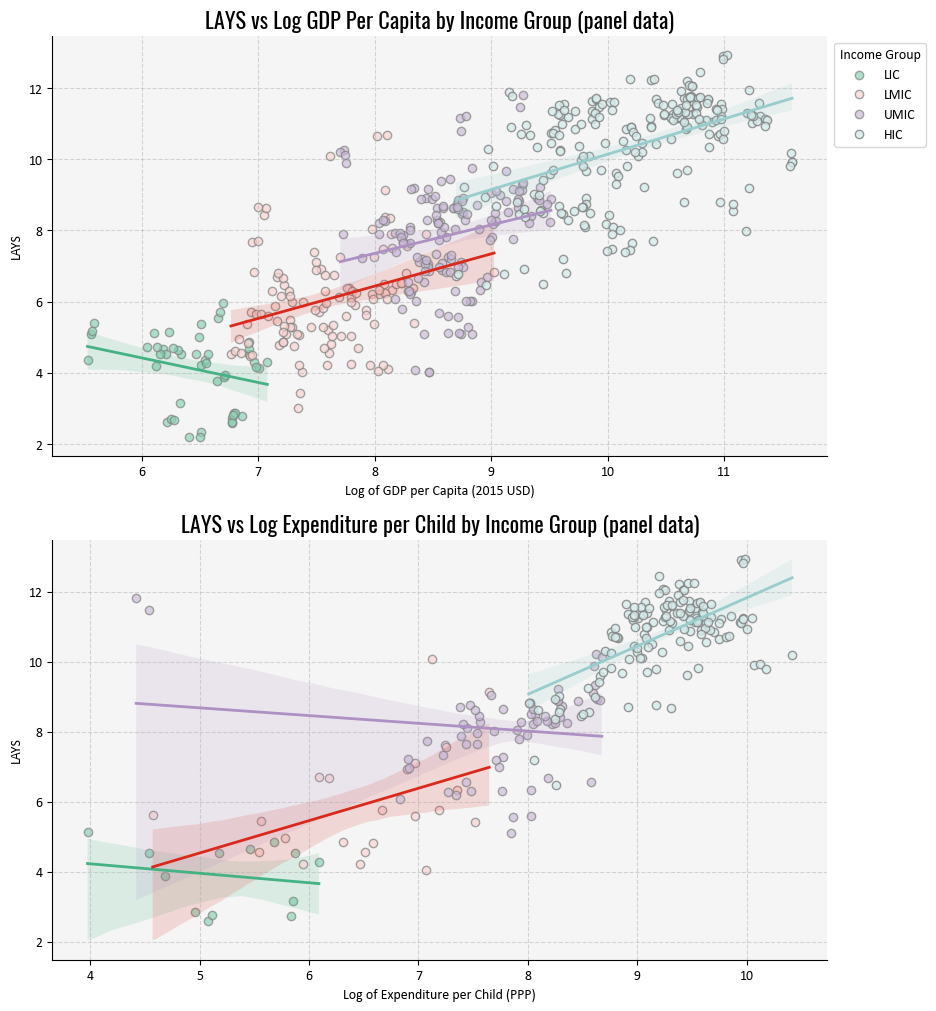

In [35]:
#========================================
# Fit and plot separate log-GDPPC slopes by income group
#========================================

## MODEL 5: Models per Income Group

df_lic = df[df['income_group'] == 'Low income'].copy()
df_lmic = df[df['income_group'] == 'Lower middle income'].copy()
df_umic = df[df['income_group'] == 'Upper middle income'].copy()
df_hic = df[df['income_group'] == 'High income'].copy()

fig, ax = plt.subplots(2, 1, figsize=(10, 12))
ax = ax.flatten()

sns.regplot(data=df_lic, 
            x="log_gdppc", 
            y="lays", 
            label="LIC", 
            scatter_kws={"color": sc_colors["medium green"], 
                         "edgecolor": 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["green"], "lw": 2},
            ax=ax[0])
sns.regplot(data=df_lmic, 
            x="log_gdppc", 
            y="lays", ax=ax[0], 
            label="LMIC",
            scatter_kws={"color": sc_colors["light red"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["red"], "lw": 2})
sns.regplot(data=df_umic, 
            x="log_gdppc", 
            y="lays", ax=ax[0], 
            label="UMIC", 
            scatter_kws={"color": sc_colors["medium purple"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["purple"], "lw": 2})
sns.regplot(data=df_hic, 
            x="log_gdppc", 
            y="lays", ax=ax[0], 
            label="HIC", 
            scatter_kws={"color": sc_colors["medium blue"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.8}, 
            line_kws={"color": sc_colors["blue"], "lw": 2})

ax[0].legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1))
ax[0].set_xlabel("Log of GDP per Capita (2015 USD)")
ax[0].set_ylabel("LAYS")
ax[0].set_title("LAYS vs Log GDP Per Capita by Income Group (panel data)", 
             fontsize=16, 
             fontname='Oswald')

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_facecolor('whitesmoke')
ax[0].grid(True, linestyle='--', alpha=0.5)

#==============================================================
# Fit and plot separate log-Expenditure per Child slopes by income group
#==============================================================

sns.regplot(data=df_lic, 
            x="log_pcppp", 
            y="lays", 
            label="LIC", 
            scatter_kws={"color": sc_colors["medium green"], 
                         "edgecolor": 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["green"], "lw": 2},
            ax=ax[1])
sns.regplot(data=df_lmic, 
            x="log_pcppp", 
            y="lays", ax=ax[1], 
            label="LMIC",
            scatter_kws={"color": sc_colors["light red"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["red"], "lw": 2})
sns.regplot(data=df_umic, 
            x="log_pcppp", 
            y="lays", ax=ax[1], 
            label="UMIC", 
            scatter_kws={"color": sc_colors["medium purple"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["purple"], "lw": 2})
sns.regplot(data=df_hic, 
            x="log_pcppp", 
            y="lays", ax=ax[1], 
            label="HIC", 
            scatter_kws={"color": sc_colors["medium blue"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.8}, 
            line_kws={"color": sc_colors["blue"], "lw": 2})


ax[1].legend().set_visible(False)
ax[1].set_xlabel("Log of Expenditure per Child (PPP)")
ax[1].set_ylabel("LAYS")
ax[1].set_title("LAYS vs Log Expenditure per Child by Income Group (panel data)", 
             fontsize=16, 
             fontname='Oswald')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_facecolor('whitesmoke')
ax[1].grid(True, linestyle='--', alpha=0.5)

fig.savefig(FIG_DIR / "panel_lays_vs_log_pcppp_by_income_group.png", 
            dpi=300, 
            bbox_inches="tight")

In [34]:
#========================================
# Estimate separate OLS models by income group
#========================================

# MODEL 3a.1 - Low Income Countries - GDPPC-LAYS relationship

y = df_lic["lays"]
X = df_lic[["log_gdppc"]]
X = sm.add_constant(X)
model_3a_1 = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print("\n\nModel 3a.1 - Low Income Countries Summary:")
print(model_3a_1.summary)

# MODEL 3a.2 - Low Income Countries - PCPPP-LAYS relationship

df_lic = df_lic.dropna(subset=["log_pcppp"])

y = df_lic["lays"]
X = df_lic[["log_pcppp"]]
X = sm.add_constant(X)
model_3a_2 = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print("\n\nModel 3a.2 - Low Income Countries Summary:")
print(model_3a_2.summary)

# MODEL 3b.1 - Lower Middle Income Countries - GDPPC-LAYS relationship
y = df_lmic["lays"]
X = df_lmic[["log_gdppc"]]
X = sm.add_constant(X)
model_3b_1 = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print("\n\nModel 3b.1 - Lower Middle Income Countries Summary:")
print(model_3b_1.summary)

# MODEL 3b.2 - Lower Middle Income Countries - PCPPP-LAYS relationship

df_lmic = df_lmic.dropna(subset=["log_pcppp"])

y = df_lmic["lays"]
X = df_lmic[["log_pcppp"]]
X = sm.add_constant(X)
model_3b_2 = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print("\n\nModel 3b.2 - Lower Middle Income Countries Summary:")
print(model_3b_2.summary)

# MODEL 3c.1 - Upper Middle Income Countries - GDPPC-LAYS relationship
y = df_umic["lays"]
X = df_umic[["log_gdppc"]]
X = sm.add_constant(X)
model_3c_1 = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print("\n\nModel 3c.1 - Upper Middle Income Countries Summary:")
print(model_3c_1.summary)

# MODEL 3c.2 - Upper Middle Income Countries - PCPPP-LAYS relationship

df_umic = df_umic.dropna(subset=["log_pcppp"])

y = df_umic["lays"]
X = df_umic[["log_pcppp"]]
X = sm.add_constant(X)
model_3c_2 = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print("\n\nModel 3c.2 - Upper Middle Income Countries Summary:")
print(model_3c_2.summary)

# MODEL 3d.1 - High Income Countries - GDPPC-LAYS relationship
y = df_hic["lays"]
X = df_hic[["log_gdppc"]]
X = sm.add_constant(X)
model_3d_1 = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print("\n\nModel 3d.1 - High Income Countries Summary:")
print(model_3d_1.summary)

# MODEL 3d.2 - High Income Countries - PCPPP-LAYS relationship

df_hic = df_hic.dropna(subset=["log_pcppp"])

y = df_hic["lays"]
X = df_hic[["log_pcppp"]]
X = sm.add_constant(X)
model_3d_2 = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print("\n\nModel 3d.2 - High Income Countries Summary:")
print(model_3d_2.summary)



Model 3a.1 - Low Income Countries Summary:
                          PanelOLS Estimation Summary                           
Dep. Variable:                   lays   R-squared:                        0.3700
Estimator:                   PanelOLS   R-squared (Between):             -3.0885
No. Observations:                  49   R-squared (Within):               0.3700
Date:                Tue, May 26 2026   R-squared (Overall):             -2.9099
Time:                        15:18:43   Log-likelihood                    2.1254
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.798
Entities:                          16   P-value                           0.0001
Avg Obs:                       3.0625   Distribution:                    F(1,32)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):   

In [36]:
#========================================
# Compile subgroup coefficients into a summary table
#========================================

coefficients = [(model_3a_1.params.to_list())[1],
                (model_3a_2.params.to_list())[1],
                (model_3b_1.params.to_list())[1], 
                (model_3b_2.params.to_list())[1], 
                (model_3c_1.params.to_list())[1], 
                (model_3c_2.params.to_list())[1], 
                (model_3d_1.params.to_list())[1], 
                (model_3d_2.params.to_list())[1]]

pvalues = [(model_3a_1.pvalues.to_list())[1], 
           (model_3a_2.pvalues.to_list())[1], 
           (model_3b_1.pvalues.to_list())[1], 
           (model_3b_2.pvalues.to_list())[1], 
           (model_3c_1.pvalues.to_list())[1], 
           (model_3c_2.pvalues.to_list())[1], 
           (model_3d_1.pvalues.to_list())[1], 
           (model_3d_2.pvalues.to_list())[1]]

income_groups = ['Low Income',
                    'Low Income',
                    'Lower Middle Income',
                    'Lower Middle Income',
                    'Upper Middle Income',
                    'Upper Middle Income',
                    'High Income',
                    'High Income']

predictor = ['Log GDPPC',
             'Log Expenditure per Child',
             'Log GDPPC',
             'Log Expenditure per Child',
             'Log GDPPC',
             'Log Expenditure per Child',
             'Log GDPPC',
             'Log Expenditure per Child']

models = ['model_3a_1', 'model_3a_2',
          'model_3b_1', 'model_3b_2',
          'model_3c_1', 'model_3c_2',
          'model_3d_1', 'model_3d_2']

n = [model_3a_1.nobs, model_3a_2.nobs, 
     model_3b_1.nobs, model_3b_2.nobs, 
     model_3c_1.nobs, model_3c_2.nobs, 
     model_3d_1.nobs, model_3d_2.nobs]

r2 = [eval(model).rsquared for model in models]

table = pd.DataFrame({
    'Model': models,
    'r2': r2,
    'Income Group': income_groups,
    'Predictor': predictor,
    'Coefficient': coefficients,
    'P-value': pvalues,
    'N': n})

table = table.round(3)
table.to_csv(TAB_DIR / "panel_income_group_log_gdppc_slopes.csv", index=False)

table

,Model,r2,Income Group,Predictor,Coefficient,P-value,N
0,model_3a_1,0.370,Low Income,Log GDPPC,3.898,0.002,49
1,model_3a_2,0.687,Low Income,Log Expenditure per Child,0.232,0.007,13
2,model_3b_1,0.120,Lower Middle Income,Log GDPPC,1.340,0.007,118
3,model_3b_2,0.908,Lower Middle Income,Log Expenditure per Child,4.352,0.000,23
4,model_3c_1,0.128,Upper Middle Income,Log GDPPC,1.759,0.000,140
5,model_3c_2,0.144,Upper Middle Income,Log Expenditure per Child,0.716,0.023,64
6,model_3d_1,0.001,High Income,Log GDPPC,0.078,0.852,210
7,model_3d_2,0.000,High Income,Log Expenditure per Child,0.028,0.915,141


In [52]:
coefs = []

countries = df_lic.index.get_level_values("iso3").unique()

for c in countries:
    sub = df_lic[df_lic.index.get_level_values("iso3") != c].dropna(subset=["lays", "log_pcppp"])
    
    if sub.index.get_level_values("iso3").nunique() < 2:
        continue
    if sub["log_pcppp"].nunique() < 2:
        continue
    
    try:
        model = PanelOLS(
            sub["lays"],
            sm.add_constant(sub["log_pcppp"]),
            entity_effects=True
        )
        res = model.fit(cov_type="unadjusted")
        coefs.append(res.params["log_pcppp"])
    except ZeroDivisionError:
        continue

print("LOO Coefficients for log_pcppp in LICs:")
print(f"Minimum possible coefficient: {round(min(coefs), 3)}")
print(f"Maximum possible coefficient: {round(max(coefs), 3)}\n")

print(f"Ratio of maximum coefficient to minimum (smaller is better): {round(max(coefs)/min(coefs), 3)}\n\n")


coefs = []

countries = df_lmic.index.get_level_values("iso3").unique()

for c in countries:
    sub = df_lmic[df_lmic.index.get_level_values("iso3") != c].dropna(subset=["lays", "log_pcppp"])
    
    if sub.index.get_level_values("iso3").nunique() < 2:
        continue
    if sub["log_pcppp"].nunique() < 2:
        continue
    
    try:
        model = PanelOLS(
            sub["lays"],
            sm.add_constant(sub["log_pcppp"]),
            entity_effects=True
        )
        res = model.fit(cov_type="unadjusted")
        coefs.append(res.params["log_pcppp"])
    except ZeroDivisionError:
        continue

print("LOO Coefficients for log_pcppp in LMICs:")
print(f"Minimum possible coefficient: {round(min(coefs), 3)}")
print(f"Maximum possible coefficient: {round(max(coefs), 3)}\n")
print(f"Ratio of maximum coefficient to minimum (smaller is better): {round(max(coefs)/min(coefs), 3)}\n\n")

LOO Coefficients for log_pcppp in LICs:
Minimum possible coefficient: 0.232
Maximum possible coefficient: 0.245

Ratio of maximum coefficient to minimum (smaller is better): 1.057


LOO Coefficients for log_pcppp in LMICs:
Minimum possible coefficient: 3.05
Maximum possible coefficient: 4.667

Ratio of maximum coefficient to minimum (smaller is better): 1.53




## Proportionate Expenditure and LAYS (Panel Data)


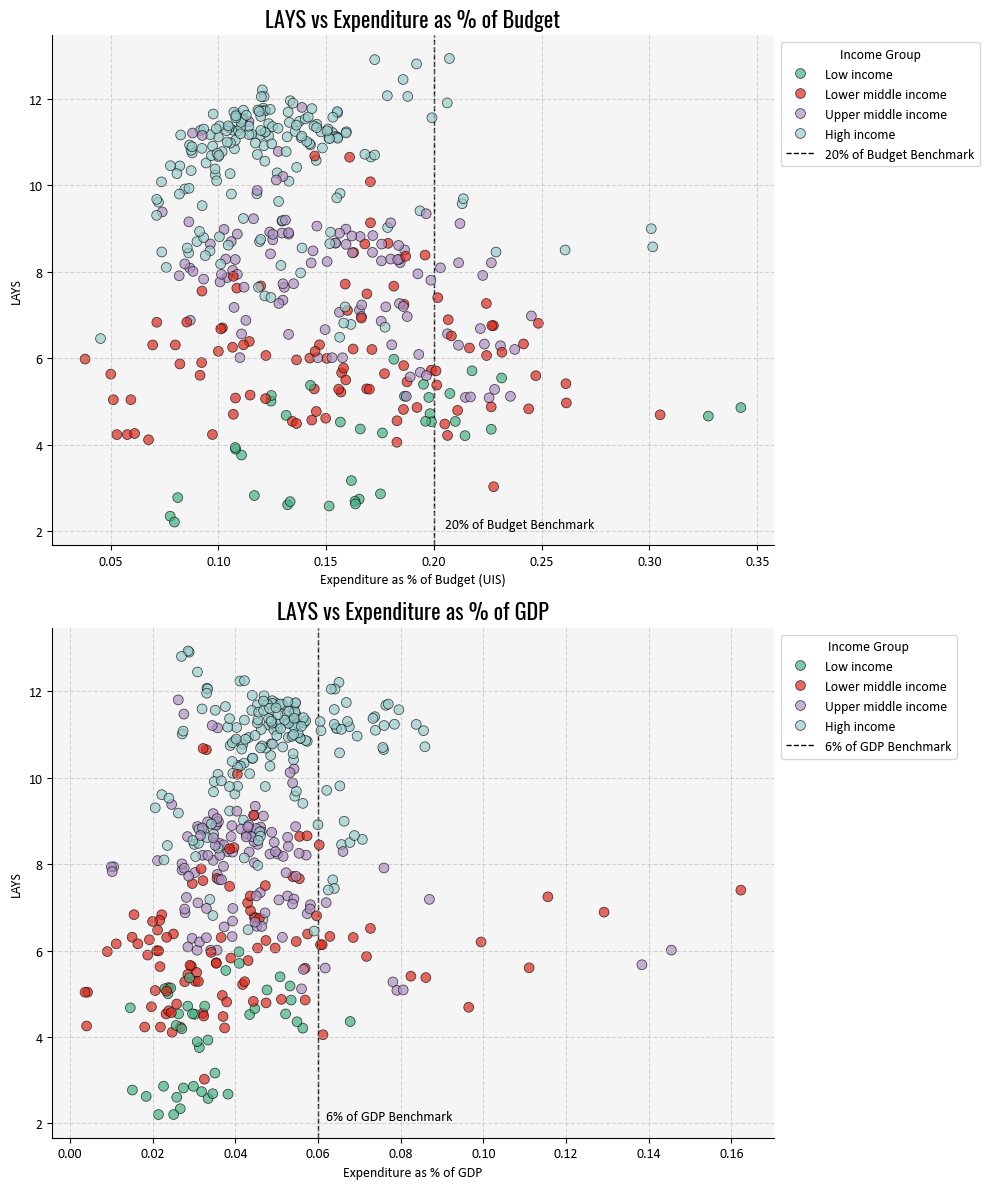

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 12))

work = df.copy()

sns.scatterplot(data=work, x="expenditure_pctbudget_uis", y="lays",
                hue="income_group",
                palette={"Low income": sc_colors['green'], 
                         "Lower middle income": sc_colors['red'], 
                         "Upper middle income": sc_colors['purple'], 
                         "High income": sc_colors['blue']},
                edgecolor='black', 
                alpha=0.7, 
                s=50, 
                ax=ax[0])

ax[0].axvline(x=.2, color='black', linestyle='--', lw=1, label="20% of Budget Benchmark", zorder=0)
ax[0].text(0.205, 2, "20% of Budget Benchmark", verticalalignment='bottom', fontsize=10)

ax[0].set_title("LAYS vs Expenditure as % of Budget", fontsize=16, fontname='Oswald')
ax[0].set_xlabel("Expenditure as % of Budget (UIS)")
ax[0].set_ylabel("LAYS")
ax[0].legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1))
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_facecolor('whitesmoke')
ax[0].spines[['top', 'right']].set_visible(False)


sns.scatterplot(data=work, x="expenditure_pctgdp", y="lays",
                hue="income_group",
                palette={"Low income": sc_colors['green'], 
                         "Lower middle income": sc_colors['red'], 
                         "Upper middle income": sc_colors['purple'], 
                         "High income": sc_colors['blue']},
                edgecolor='black', 
                alpha=0.7,
                s=50,
                ax=ax[1])

ax[1].axvline(x=.06, color='black', linestyle='--', lw=1, label="6% of GDP Benchmark", zorder=0)
ax[1].text(0.062, 2, "6% of GDP Benchmark", verticalalignment='bottom', fontsize=10)

ax[1].set_title("LAYS vs Expenditure as % of GDP", fontsize=16, fontname='Oswald')
ax[1].set_xlabel("Expenditure as % of GDP")
ax[1].set_ylabel("LAYS")
ax[1].legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1)).set_visible(True)
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_facecolor('whitesmoke')
ax[1].spines[['top', 'right']].set_visible(False)

plt.savefig(FIG_DIR / "lays_vs_expenditure_pctbudget_and_pctgdp.png", dpi=300, bbox_inches="tight")

plt.tight_layout()

In [63]:
#=============================================================================
# Estimate linear models for LAYS vs Expenditure as % of Budget and % of GDP
#=============================================================================

df4 = df.copy()
df4 = df4.dropna(subset=["expenditure_pctbudget_uis", "expenditure_pctgdp"])

df4['log_gdppc_s'] = (df4["log_gdppc"] - df4["log_gdppc"].mean()) / df4["log_gdppc"].std()
df4['pct_budget_s'] = (df4["expenditure_pctbudget_uis"] - df4["expenditure_pctbudget_uis"].mean()) / df4["expenditure_pctbudget_uis"].std()
df4['pct_gdp_s'] = (df4["expenditure_pctgdp"] - df4["expenditure_pctgdp"].mean()) / df4["expenditure_pctgdp"].std()

y = df4["lays"]

X = df4[["log_gdppc_s", "pct_budget_s"]]
X = sm.add_constant(X)
model4a = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)

#==================================================================================================================================================
# Add interactions with dummies for income groups to test whether the relationship between expenditure as % of GDP and LAYS varies by income group
#==================================================================================================================================================

interaction_terms = []
for col in dummies.columns:
    interaction_term = df4["pct_budget_s"] * df4[col]
    df4[f"pct_budget_s_{col}"] = interaction_term
    interaction_terms.append(f"pct_budget_s_{col}")


y = df4["lays"]

X = df4[["log_gdppc_s", "pct_budget_s"] + interaction_terms]
X = sm.add_constant(X)
model4b = PanelOLS(y, X, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)

print("\n\nModel 4a - LAYS vs Expenditure as % of Budget Summary (Country FE):")
print(model4a.summary)

print("\n\nModel 4b - LAYS vs Expenditure as % of budget, with income group interactions (Country FE):")
print(model4b.summary)




Model 4a - LAYS vs Expenditure as % of Budget Summary (Country FE):
                          PanelOLS Estimation Summary                           
Dep. Variable:                   lays   R-squared:                        0.0632
Estimator:                   PanelOLS   R-squared (Between):              0.6015
No. Observations:                 417   R-squared (Within):               0.0632
Date:                Tue, May 26 2026   R-squared (Overall):              0.6180
Time:                        15:34:51   Log-likelihood                   -88.075
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.0736
Entities:                         146   P-value                           0.0002
Avg Obs:                       2.8562   Distribution:                   F(2,269)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000  

### Robustness Check

iteratively remove countries to check the level of variance in coefficients to see whether significance is driven by outliers in a small n sample. Values close to each other and with the same sign show that this is not an issue, and increase trust in findings. A ratio of 1 between max and min would be perfect. 

In [62]:
coefs = []

df_lic = df4[df4['income_group'] == 'Low income']
countries = df_lic.index.get_level_values("iso3").unique()

for c in countries:
    sub = df_lic[df_lic.index.get_level_values("iso3") != c]
    
    model = PanelOLS(
        sub["lays"],
        sm.add_constant(sub["pct_budget_s"]),
        entity_effects=True
    )
    
    res = model.fit(cov_type='clustered', cluster_entity=True)
    coefs.append(res.params["pct_budget_s"])

print("LOO Coefficients for pct_budget_s in LMICs:")
print(f"Minimum possible coefficient: {round(min(coefs), 3)}")
print(f"Maximum possible coefficient: {round(max(coefs), 3)}\n")
print(f"Ratio of maximum coefficient to minimum (closer to 1 is better): {round(max(coefs)/min(coefs), 3)}\n\n")

coefs = []

df_lmic = df4[df4['income_group'] == 'Lower middle income']
countries = df_lmic.index.get_level_values("iso3").unique()

for c in countries:
    sub = df_lmic[df_lmic.index.get_level_values("iso3") != c]
    
    model = PanelOLS(
        sub["lays"],
        sm.add_constant(sub["pct_budget_s"]),
        entity_effects=True
    )
    
    res = model.fit(cov_type='clustered', cluster_entity=True)
    coefs.append(res.params["pct_budget_s"])

print("LOO Coefficients for pct_budget_s in LMICs:")
print(f"Minimum possible coefficient: {round(min(coefs), 3)}")
print(f"Maximum possible coefficient: {round(max(coefs), 3)}\n")
print(f"Ratio of maximum coefficient to minimum (closer to 1 is better): {round(max(coefs)/min(coefs), 3)}\n\n")

LOO Coefficients for pct_budget_s in LMICs:
Minimum possible coefficient: 0.041
Maximum possible coefficient: 0.2

Ratio of maximum coefficient to minimum (closer to 1 is better): 4.853


LOO Coefficients for pct_budget_s in LMICs:
Minimum possible coefficient: -0.166
Maximum possible coefficient: -0.067

Ratio of maximum coefficient to minimum (closer to 1 is better): 0.403




## PanelOLS Models: GDP per Capita and Expenditure per Child (with Country Fixed Effects)

This section fits linear, log, and quartic models relating LAYS to GDP per capita and Expenditure per Child, using entity (country) fixed effects. The results show how the relationship between education outcomes and economic resources varies with model specification.

Light Robustness test. Repeatedly running my regression for LICs, leaving one country out each time to see if my small sample is being skewed by outliers. The difference between the smallest and largest coefficients is small, implying that this is not the case. Given that this is not high stakes analysis, this gives me enough confidence to report on the data. 


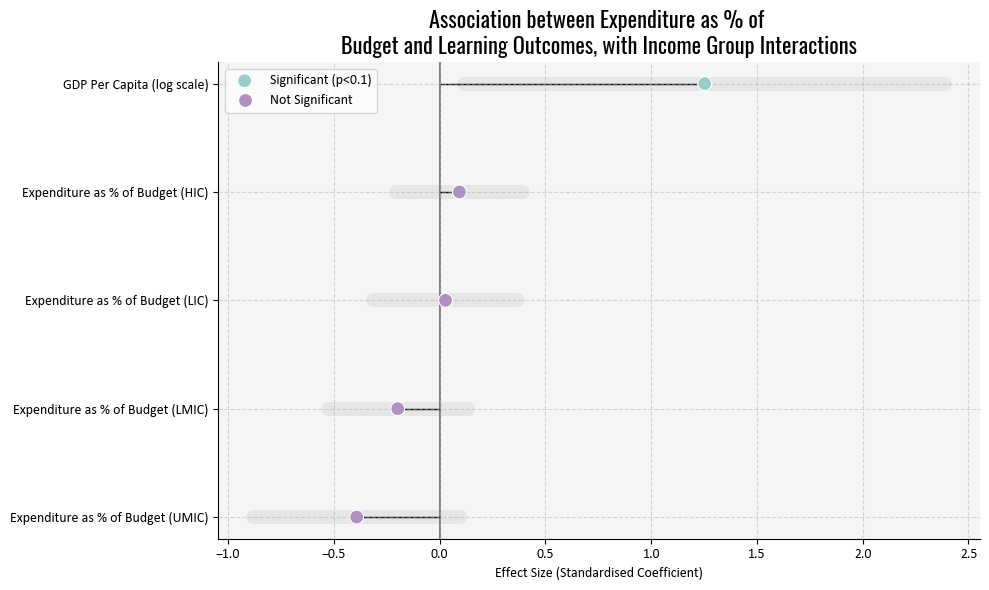

In [82]:
#=============================================================================
# Visualise interaction effects for expenditure as % of budget by income group
#=============================================================================

model = model4b
variables = ["GDP Per Capita (log scale)", 
             "Expenditure as % of Budget (HIC)", 
             "Expenditure as % of Budget (LIC)", 
             "Expenditure as % of Budget (LMIC)", 
             "Expenditure as % of Budget (UMIC)"]

title = "Association between Expenditure as % of \nBudget and Learning Outcomes, with Income Group Interactions"


ci = model.conf_int(level=0.90)

model_df = pd.DataFrame({
    "Variable": variables,
    "Coefficient": model.params[1:].values,
    "CI Lower": ci.iloc[1:, 0].values,
    "CI Upper": ci.iloc[1:, 1].values,
    "Significant": model.pvalues[1:].values < 0.1
})

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('white')

sns.scatterplot(x=model_df["Coefficient"], y=model_df["Variable"], hue=model_df["Significant"], palette={True: sc_colors['blue'], False: sc_colors['purple']}, s=100, ax=ax, zorder=2)

ax.axvline(x=0, color='grey', linestyle='-', zorder=1)

ax.set_facecolor('whitesmoke')
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax.hlines(model_df['Variable'], 0, model_df['Coefficient'], color="black", linestyles="-", linewidth=1, zorder=1)

ax.hlines(y=model_df['Variable'],
    xmin=model_df['CI Lower'],
    xmax=model_df['CI Upper'],
    linewidth=10,
    capstyle="round",
    color=sc_colors['grey'],
    zorder=0
)

plt.xlabel("Effect Size (Standardised Coefficient)")
plt.title(title, fontname='Oswald', fontsize=16)
plt.legend(loc='upper left', labels=['Significant (p<0.1)', 'Not Significant'])
ax.spines[['right','top']].set_visible(False)
ax.set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 1])

plt.show()

## **Change in LAYS and Budget over Time**

This uses annualised panel data from lays_panels. This captures figures for baseline (earliest year in panel) and delta_ (change across a panel annualised). There are multiple panels covering different time period, but when aggregated we take the average annualised change across panels for a country. 


### Prepare annualised data for visualisation

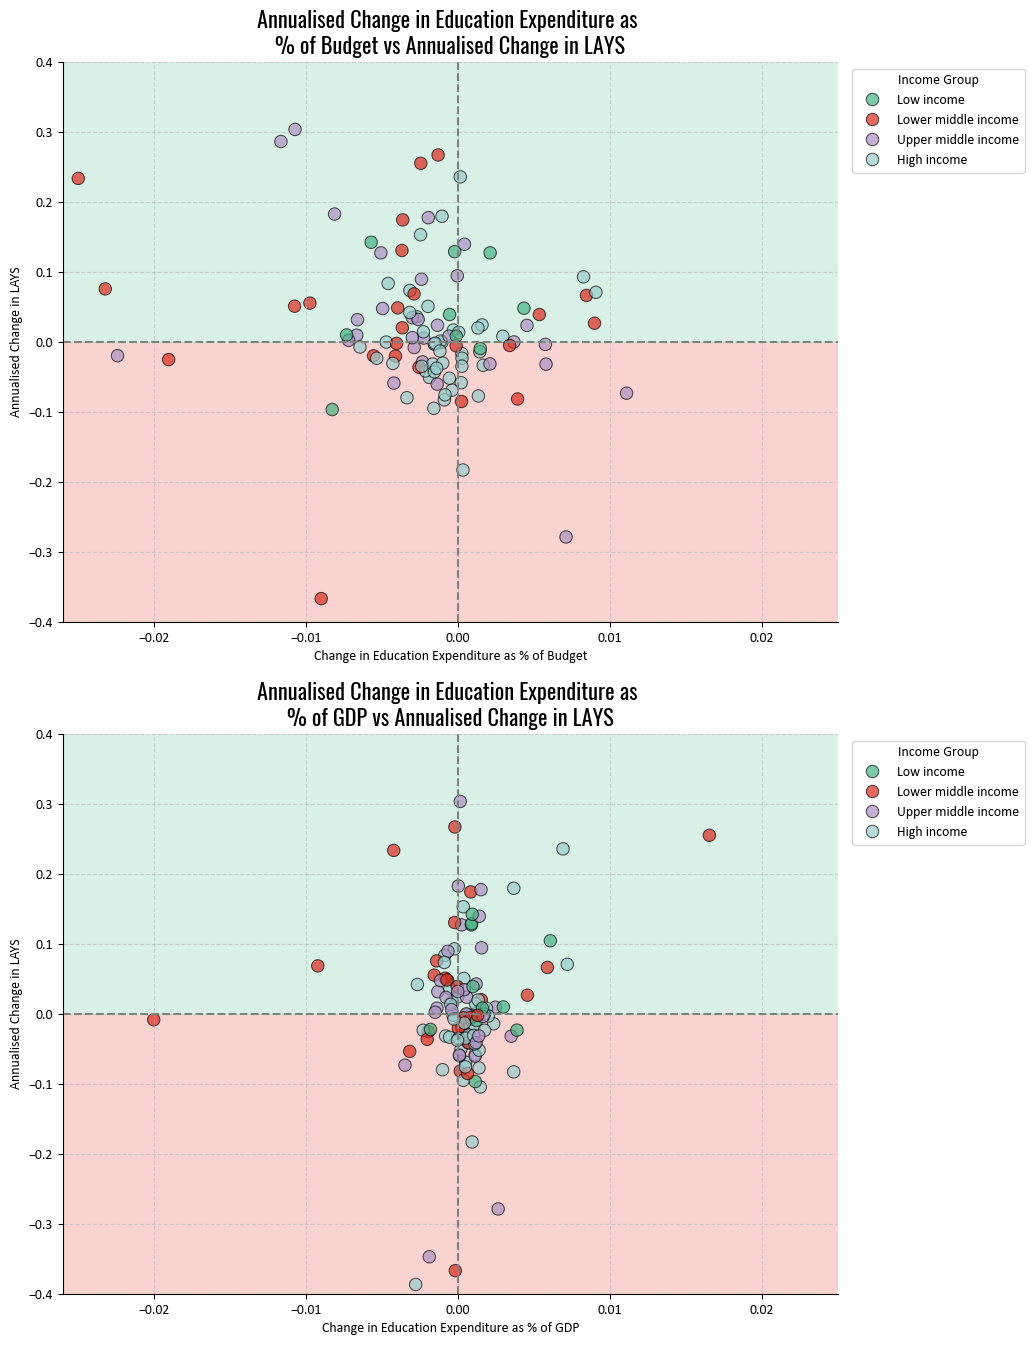

In [83]:

#=====================================================================
# Prepare panel dataset for plotting change in education expenditure vs change in LAYS
#=====================================================================

df4 = lays_panels.copy()
df4 = lays_panels[lays_panels['panel'].isin([1, 2, 3, 4, 5])]

agg_map = {col: 'mean' for col in df4.columns if col not in ['iso3', 'income_group']}
agg_map['income_group'] = 'first'
df4 = df4.groupby('iso3', as_index=False).agg(agg_map)

df4 = df4[df4['income_group'].isin(['Low income', 'Lower middle income', 'Upper middle income', 'High income'])]

#=============================================================================================
# Plot change in education budget share against change in LAYS
#=============================================================================================

fig, ax = plt.subplots(2, 1, figsize=(10, 16))

ax[0].add_patch(Rectangle(( -0.03, -0.4), 0.06, 0.4, fill=True, color=sc_colors['light red'], alpha=1))
ax[0].add_patch(Rectangle((-0.03, 0), 0.06, 0.4, fill=True, color=sc_colors['light green'], alpha=1))


ax[0].axhline(0, color='grey', linestyle='--')
ax[0].axvline(0, color='grey', linestyle='--')

sns.scatterplot(data=df4, x='delta_expenditure_pctbudget_uis', 
                y='delta_lays',
                hue='income_group', 
                # style='panel',
                palette={"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue'],
                            'Not classified': sc_colors['grey']},
                s=80,
                edgecolor='black',
                alpha=0.7,
                ax=ax[0]) 


ax[0].set_xlim(-0.026, 0.025)
ax[0].set_xlabel("Change in Education Expenditure as % of Budget")
ax[0].set_ylabel("Annualised Change in LAYS")
ax[0].set_title("Annualised Change in Education Expenditure as \n% of Budget vs Annualised Change in LAYS", fontsize=16, fontname='Oswald')
ax[0].set_ylim(-.4, .4)

ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_facecolor('whitesmoke')
ax[0].spines[['top', 'right']].set_visible(False)

ax[0].legend(title='Income Group', bbox_to_anchor=(1.01, 1), loc='upper left')

#=============================================================================
# Plot change in share of GDP spent on education against change in LAYS
#=============================================================================


ax[1].add_patch(Rectangle(( -0.03, -0.4), 0.06, 0.4, fill=True, color=sc_colors['light red'], alpha=1))
ax[1].add_patch(Rectangle((-0.03, 0), 0.06, 0.4, fill=True, color=sc_colors['light green'], alpha=1))


ax[1].axhline(0, color='grey', linestyle='--')
ax[1].axvline(0, color='grey', linestyle='--')

sns.scatterplot(data=df4, x='delta_expenditure_pctgdp', 
                y='delta_lays',
                hue='income_group', 
                # style='panel',
                palette={"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue'],
                            'Not classified': sc_colors['grey']},
                s=80,
                edgecolor='black',
                alpha=0.7,
                ax=ax[1]) 


ax[1].set_xlim(-0.026, 0.025)
ax[1].set_xlabel("Change in Education Expenditure as % of GDP")
ax[1].set_ylabel("Annualised Change in LAYS")
ax[1].set_title("Annualised Change in Education Expenditure as \n% of GDP vs Annualised Change in LAYS", fontsize=16, fontname='Oswald')
ax[1].set_ylim(-.4, .4)

ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_facecolor('whitesmoke')
ax[1].spines[['top', 'right']].set_visible(False)

ax[1].legend(title='Income Group', bbox_to_anchor=(1.01, 1), loc='upper left')


fig.savefig(FIG_DIR / "delta_expenditure_vs_delta_lays.png", dpi=300, bbox_inches="tight")

In [89]:
df5 = df4.copy()
df5 = df5[['iso3',
            'income_group',
            'panel',
            'delta_lays', 
             'baseline_gdppc_2015_usd',
             'delta_gdppc_2015_usd',
             'delta_expenditure_pctbudget_uis',
             'baseline_expenditure_pctgdp',
             'delta_expenditure_pctgdp',
             'baseline_expenditure_pctbudget_uis']]

df5['log_baseline_gdppc'] = np.log(df5['baseline_gdppc_2015_usd'])


### Simple OLS for LAYS on delta_expenditure

In [94]:
#===========================================================================================================================================
# MODEL 5a: Linear regression of change in LAYS on change in expenditure as % of budget, controlling for baseline GDPPC
#===========================================================================================================================================

df5a = df5.dropna(subset=['baseline_expenditure_pctgdp', 'delta_expenditure_pctgdp', 'delta_lays', 'log_baseline_gdppc'])

X = df5a[['baseline_expenditure_pctgdp', 'delta_expenditure_pctgdp', "log_baseline_gdppc"]]
X = sm.add_constant(X)
y = df5a["delta_lays"]
model5a = sm.OLS(y, X).fit(cov_type="HC3")

print("\n\nModel 5a - Change in LAYS vs Change in Expenditure as % of Budget, controlling for baseline GDPPC:")

print(model5a.summary())



Model 5a - Change in LAYS vs Change in Expenditure as % of Budget, controlling for baseline GDPPC:
                            OLS Regression Results                            
Dep. Variable:             delta_lays   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     3.276
Date:                Tue, 26 May 2026   Prob (F-statistic):             0.0236
Time:                        15:49:47   Log-Likelihood:                 97.677
No. Observations:                 121   AIC:                            -187.4
Df Residuals:                     117   BIC:                            -176.2
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------

## Run Logistic Regression of Improvement in LAYS on Increased Budget Share

In [128]:
df6 = df5.copy()

df6 = df6[df6['income_group'].isin(['Low income', 'Lower middle income', 'Upper middle income', 'High income'])]

df6['increased_lays'] = (df6['delta_lays'] > 0).astype(int)
df6['increased_pctbudget'] = (df6['delta_expenditure_pctbudget_uis'] > 0).astype(int)
df6['increased_pctgdp'] = (df6['delta_expenditure_pctgdp'] > 0).astype(int)

X = df6[['increased_pctbudget', 'log_baseline_gdppc']]
X = sm.add_constant(X)
y = df6['increased_lays']
model6 = sm.Logit(y, X).fit(cov_type="HC3")

print("\n\nModel 6 - Logistic regression of increase in LAYS on increase in expenditure as % of budget, controlling for baseline GDPPC:")
print(model6.summary())

Optimization terminated successfully.
         Current function value: 0.667790
         Iterations 4


Model 6 - Logistic regression of increase in LAYS on increase in expenditure as % of budget, controlling for baseline GDPPC:
                           Logit Regression Results                           
Dep. Variable:         increased_lays   No. Observations:                  145
Model:                          Logit   Df Residuals:                      142
Method:                           MLE   Df Model:                            2
Date:                Tue, 26 May 2026   Pseudo R-squ.:                 0.03496
Time:                        16:48:05   Log-Likelihood:                -96.830
converged:                       True   LL-Null:                       -100.34
Covariance Type:                  HC3   LLR p-value:                   0.02996
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [129]:
odds_df = oddsratio(model6)
display(odds_df)

,Coefficient,Std Err,z,P>|z|,Odds Ratio,OR Lower CI,OR Upper CI
const,2.916686,1.146508,2.543973,0.010960,18.4799,1.9534,174.8276
increased_pctbudget,-0.225894,0.410928,-0.549717,0.582513,0.7978,0.3565,1.7852
log_baseline_gdppc,-0.315298,0.128079,-2.461744,0.013826,0.7296,0.5676,0.9378


# **Exports**

Important communication outputs are exported in the same cells where they are produced.
Figures are saved to `Results/figures/` via `FIG_DIR`; summary tables are saved to `Results/tables/` via `TAB_DIR`.